In [1]:
import pandas as pd
import numpy as np
insurance_df = pd.read_excel(r"C:\D-A project\Insurance Data.xlsx")
insurance_df


,Age,Gender,Marital Status,Family Members,Education,Occupation,Job Title,Income,Current Product,Current Product Type,Current_Coverage,New Product Type,New_Coverage,Rating,Converted,Status
0,18.0,M,Single,3.0,NE,SPT,DD,1.000000,No,NO,0.0,INV,15000000.0,Cold,Converted,Converted
1,46.0,M,Married,5.0,PD,SE,FH,2.508402,Yes,TLE,50000.0,ANS,2000000.0,Cold,NotConverted,AS
2,23.0,M,Married,2.0,BD,SPT,PG,9.000000,No,NO,0.0,ANS,1000000.0,Hot,Converted,Converted
3,20.0,M,Single,6.0,NE,SPT,OM,2.416838,No,NO,0.0,END,1000000.0,Warm,Converted,Converted
4,48.0,NaN,Married,4.0,BD,SPT,PG,9.636769,Yes,ANS,15000000.0,INV,15000000.0,Warm,NotConverted,PS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,22.0,M,Single,5.0,LHS,SFT,OC,4.587865,No,NO,0.0,TLE,3000000.0,Hot,Converted,Converted
99996,45.0,F,Married,2.0,NE,SE,CB,2.000000,Yes,PMT,50000.0,ANS,15000000.0,Cold,NotConverted,QG
99997,51.0,F,Divorced,4.0,LHS,SFT,PA,7.000000,Yes,TLE,15000000.0,ANS,15000000.0,Warm,NotConverted,PN
99998,37.0,M,Single,3.0,UHS,SPT,OM,2.447314,Yes,PMT,4000000.0,TLE,2000000.0,Cold,NotConverted,PN


In [2]:
data_df = insurance_df.copy(deep = True)
data_df = data_df.rename(columns = lambda x : x.strip().replace(" ","_"))
# data_df = data_df.rename(columns = lambda x: x.strip())
data_df

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,18.0,M,Single,3.0,NE,SPT,DD,1.000000,No,NO,0.0,INV,15000000.0,Cold,Converted,Converted
1,46.0,M,Married,5.0,PD,SE,FH,2.508402,Yes,TLE,50000.0,ANS,2000000.0,Cold,NotConverted,AS
2,23.0,M,Married,2.0,BD,SPT,PG,9.000000,No,NO,0.0,ANS,1000000.0,Hot,Converted,Converted
3,20.0,M,Single,6.0,NE,SPT,OM,2.416838,No,NO,0.0,END,1000000.0,Warm,Converted,Converted
4,48.0,NaN,Married,4.0,BD,SPT,PG,9.636769,Yes,ANS,15000000.0,INV,15000000.0,Warm,NotConverted,PS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,22.0,M,Single,5.0,LHS,SFT,OC,4.587865,No,NO,0.0,TLE,3000000.0,Hot,Converted,Converted
99996,45.0,F,Married,2.0,NE,SE,CB,2.000000,Yes,PMT,50000.0,ANS,15000000.0,Cold,NotConverted,QG
99997,51.0,F,Divorced,4.0,LHS,SFT,PA,7.000000,Yes,TLE,15000000.0,ANS,15000000.0,Warm,NotConverted,PN
99998,37.0,M,Single,3.0,UHS,SPT,OM,2.447314,Yes,PMT,4000000.0,TLE,2000000.0,Cold,NotConverted,PN


In [3]:
data_df.dtypes100000 rows × 16 columns



Age                     float64
Gender                   object
Marital_Status           object
Family_Members          float64
Education                object
Occupation               object
Job_Title                object
Income                  float64
Current_Product          object
Current_Product_Type     object
Current_Coverage        float64
New_Product_Type         object
New_Coverage            float64
Rating                   object
Converted                object
Status                   object
dtype: object

### check for the missing data

In [12]:
data_df.isnull().sum()

Age                      44
Gender                  182
Marital_Status           42
Family_Members           22
Education                46
Occupation               43
Job_Title               123
Income                   98
Current_Product          18
Current_Product_Type     33
Current_Coverage         49
New_Product_Type         47
New_Coverage            127
Rating                   44
Converted                49
Status                    0
dtype: int64

### Data engineering strategy from provided document

In [ ]:
# We will implement the imputation based on the following general strategy:
# 1. **Simple Imputation (Mean/Median/Mode):** For most standalone variables.
# 2. **Complex Imputation (Group-wise Mean/Median/Mode):** For Income, Current_Coverage, and New_Coverage.
# 3. **Conditional Imputation (Business Logic):** For Current_Product, Current_Product_Type, Current_Coverage.
# 4. **Target Variable:** Drop missing Converted rows.
# 5. **Feature Selection:** Drop Gender and Marital_Status (as in the code snippet).



In [ ]:
### Data celaning & preprocessing

In [4]:
age_mean = data_df["Age"].mean()
age_median = data_df["Age"].median()
print(age_mean," ",age_median)

39.02571131297771   39.0


In [5]:
replacement = age_maen if age_mean < age_median else age_median
replacement

39.0

In [6]:
# fill the null values of "Age" column
data_df["Age"].fillna(replacement,inplace = True)
print(f"The Age column's missing value filled with {age_median}")
# data_df["Age"].isnull().sum()

The Age column's missing value filled with 39.0


C:\Users\debas\AppData\Local\Temp\ipykernel_18676\1968637832.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Age"].fillna(replacement,inplace = True)


In [7]:
# Missing Values were imputed by considering the minimum value between the mean
# and median values which were calculated excluding the missing data
## fill missing value in "Family_Members" column.

family_mean = data_df["Family_Members"].mean()
family_median = data_df["Family_Members"].median()
print(family_mean," ",family_median)

## fill missing value in "Family_Members" column.
data_df["Family_Members"].fillna(family_mean if family_mean < family_median else family_median,inplace = True)

# data_df["Family_Members"].isnull().sum()

4.659405069115206   4.0


C:\Users\debas\AppData\Local\Temp\ipykernel_18676\930006851.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Family_Members"].fillna(family_mean if family_mean < family_median else family_median,inplace = True)


### Education, Occupation, Job_Title, New_Product_Type, Rating: Replace with Mode

In [8]:
catagorical_col = ["Education","Occupation","Job_Title","New_Product_Type","Rating"]
for col in catagorical_col:
    data_df[col].fillna(data_df[col].mode()[0],inplace = True)
    print(f"catagorical {col}'s null value replaced with :{data_df[col].mode()[0]}")

catagorical Education's null value replaced with :BD
catagorical Occupation's null value replaced with :SPT
catagorical Job_Title's null value replaced with :FH
catagorical New_Product_Type's null value replaced with :ANS
catagorical Rating's null value replaced with :Cold


C:\Users\debas\AppData\Local\Temp\ipykernel_18676\2846473939.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df[col].fillna(data_df[col].mode()[0],inplace = True)


## Handling Income Missing Values (Grouped Mean/Median)

In [9]:
## get mean and median of salary group by occupation.

group_income_mean = data_df.groupby("Occupation")["Income"].mean()
print(group_income_mean)
group_income_median = data_df.groupby("Occupation")["Income"].median()
print(group_income_median)


Occupation
SE     2.949110
SFT    2.505527
SPT    6.889731
Name: Income, dtype: float64
Occupation
SE     2.316235
SFT    2.000000
SPT    7.614226
Name: Income, dtype: float64


In [10]:
## fill the missing value of income with the minimum value between mean and median.

for occ,mean in group_income_mean.items():
    median = group_income_median[occ]

    imputation_value = min(mean,median)

    mask = (data_df["Occupation"] == occ) & (data_df["Income"].isnull())
    data_df.loc[mask,"Income"] = imputation_value
    print(f"The occupation {occ} ,mean:{mean:.2f},median:{median:.2f},filled with {imputation_value:.2f}")


The occupation SE ,mean:2.95,median:2.32,filled with 2.32
The occupation SFT ,mean:2.51,median:2.00,filled with 2.00
The occupation SPT ,mean:6.89,median:7.61,filled with 6.89


## Handling Interdependent Missing Values (Current Product, Type, Coverage)

In [24]:
### Step 1: Impute Current_Product (Yes/No)
##Strategy (from report):** If Current_Product_Type is 'NA' or Current_Coverage is 0, then Current_Product is 'No'. Otherwise, 'Yes'.

##Note: Since we are filling in order, Current_Product_Type and Current_Coverage may still have missing values (NaN) at this stage.

missing_pro_idx = data_df[data_df["Current_Product"].isnull()].index

c1 = data_df.loc[missing_pro_idx,"Current_Product_Type"] == "NO"
c2 = data_df.loc[missing_pro_idx,"Current_Coverage"] == 0.0
idx_no = data_df.loc[missing_pro_idx][c1|c2].index
data_df.loc[idx_no,"Current_Product"] = "No"
# then fill other null value with yes
data_df["Current_Product"].fillna("Yes",inplace = True)


C:\Users\debas\AppData\Local\Temp\ipykernel_18676\3805279427.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Current_Product"].fillna("Yes",inplace = True)


In [34]:
### Step 2: Impute Current_Product_Type
##Strategy (from report):** If `Current_Product` is 'No' or `Current_Coverage` is 0,
##then `Current_Product_Type` is 'NA' (using 'NO' as per the data). Otherwise, fill with Mode ('ANS').

cpt_missing_idx = data_df[data_df["Current_Product_Type"].isnull()].index
idx_cpt_no = data_df.loc[cpt_missing_idx][(data_df.loc[cpt_missing_idx,"Current_Product"] == "No") | (data_df.loc[cpt_missing_idx,"Current_Coverage"] == 0.0)].index
data_df.loc[idx_cpt_no,"Current_Product_Type"] = "NO"

In [35]:
data_df.loc[idx_cpt_no,"Current_Product_Type"]

14974    NO
14993    NO
15069    NO
15145    NO
15183    NO
15278    NO
15335    NO
15354    NO
15392    NO
15411    NO
15430    NO
15468    NO
15487    NO
15506    NO
15563    NO
15582    NO
Name: Current_Product_Type, dtype: object

In [36]:
data_df["Current_Product_Type"].isnull().sum()

np.int64(17)

In [54]:
### fill the remain null value of Current_Product_Type
data_df["Current_Product_Type"].mode()
existing_customer_idx = data_df[data_df["Current_Product_Type"] != "NO"]
replacement_mode_cpt = existing_customer_idx["Current_Product_Type"].mode()[0]
data_df["Current_Product_Type"].fillna(replacement_mode_cpt,inplace = True)
data_df["Current_Product_Type"].isnull().sum()

np.int64(0)

#### Step 3: Impute Current_Coverage

In [73]:
##Strategy (from report):** If `Current_Product` is 'No' or `Current_Product_Type` is 'NA' (NO), 
#then `Current_Coverage` is 0. Otherwise, calculate Mean/Median for the `Current_Product_Type` and fill with the lowest of the two.

cv_missing_index = data_df[data_df["Current_Coverage"].isnull()].index
total_missing_index = data_df.loc[cv_missing_index][(data_df.loc[cv_missing_index,'Current_Coverage'] == 'No') | (data_df.loc[cv_missing_index,'Current_Product_Type'] == 'NO')].index
## implement the value of Current_Coverage.
data_df.loc[total_missing_index,"Current_Coverage"] = 0.0



np.int64(26)

In [85]:
# remain null value indexs of "Current_Coverage"
remain_missing_index = data_df[data_df["Current_Coverage"].isnull()].index
remain_missing_index


Index([10053, 10072, 10148, 10300, 10338, 10376, 10414, 10490, 10547, 10756,
       10794, 10851, 10908, 11003, 11212, 11269, 11440, 11554, 11592, 11649,
       11687, 11725, 11896, 11934, 11972, 12086],
      dtype='int64')

In [97]:
non_null_cpt = data_df[data_df["Current_Product_Type"] != 'NO']

##calculate mean,median of "Current_Coverage" groupby Current_Product_Type
ccv_mean = non_null_cpt.groupby("Current_Product_Type")["Current_Coverage"].mean().round(2)
ccv_mean 

Current_Product_Type
ANS    6594115.10
END    6321112.12
INV    6914191.08
PMT    5871166.33
TLE    5963965.82
Name: Current_Coverage, dtype: float64

In [96]:
ccv_median = non_null_cpt.groupby("Current_Product_Type")["Current_Coverage"].median().round(2)
ccv_median

Current_Product_Type
ANS    3000000.0
END    3000000.0
INV    4000000.0
PMT    3000000.0
TLE    3000000.0
Name: Current_Coverage, dtype: float64

In [133]:
for cpt,mean in ccv_mean.items():
    median = ccv_median[cpt]

    replacement_val = min(mean,median)
    mask = data_df.index.isin(remain_missing_index) & (data_df["Current_Product_Type"] == cpt)
    data_df.loc[mask,"Current_Coverage"] = replacement_val
    print(f"Current_Coverage missing values filled for {cpt}: {replacement_val}")
data_df["Current_Coverage"].isnull().sum()

Current_Coverage missing values filled for ANS: 3000000.0
Current_Coverage missing values filled for END: 3000000.0
Current_Coverage missing values filled for INV: 4000000.0
Current_Coverage missing values filled for PMT: 3000000.0
Current_Coverage missing values filled for TLE: 3000000.0


np.int64(0)

### 3.4. Handling `New_Coverage` Missing Values

In [117]:
##Strategy: Group by `New_Product_Type`, calculate mean and median of `New_Coverage`, 
#and fill missing values with the lower of the two for that group.

nc_missing_index = data_df[data_df["New_Coverage"].isnull()].index
nc_mean_npt = data_df.groupby("New_Product_Type")["New_Coverage"].mean().round(2)
nc_mean_npt

New_Product_Type
ANS    6048961.12
END    6161391.91
INV    6127873.35
PMT    6438240.67
TLE    5976387.39
Name: New_Coverage, dtype: float64

In [118]:
nc_median_npt = data_df.groupby("New_Product_Type")["New_Coverage"].median()
nc_median_npt

New_Product_Type
ANS    3000000.0
END    3000000.0
INV    3000000.0
PMT    3000000.0
TLE    2000000.0
Name: New_Coverage, dtype: float64

In [134]:
for nc,mean in nc_mean_npt.items():
    median = nc_median_npt[nc]
    replace_val = min(mean,median)
    mask = data_df.index.isin(nc_missing_index) & (data_df["New_Product_Type"] == nc)
    data_df.loc[mask,"New_Coverage"] = replace_val
    print(f"New_Coverage missing values filled for {nc}:{replace_val}")
data_df["New_Coverage"].isnull().sum()

New_Coverage missing values filled for ANS:3000000.0
New_Coverage missing values filled for END:3000000.0
New_Coverage missing values filled for INV:3000000.0
New_Coverage missing values filled for PMT:3000000.0
New_Coverage missing values filled for TLE:2000000.0


np.int64(0)

### Handling Remaining Missing Values (Gender, Marital_Status)

In [138]:
# The strategy for these variables is just to impute them with the Mode, which we will do now.

data_df["Gender"].fillna(data_df["Gender"].mode()[0],inplace = True)
data_df["Marital_Status"].fillna(data_df["Marital_Status"].mode()[0],inplace = True)



C:\Users\debas\AppData\Local\Temp\ipykernel_18676\3998279417.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Marital_Status"].fillna(data_df["Marital_Status"].mode()[0],inplace = True)


## Handling Target Variable Converted

In [149]:
# drop the null value of Converted column.
data_df.dropna(subset = ["Converted"],inplace = True)
data_df["Converted"].isnull().sum()

np.int64(0)

In [153]:
## Drop column Status
data_df.drop("Status",axis = 1 ,inplace = True)

In [154]:
data_df.isnull().sum()

Age                     0
Gender                  0
Marital_Status          0
Family_Members          0
Education               0
Occupation              0
Job_Title               0
Income                  0
Current_Product         0
Current_Product_Type    0
Current_Coverage        0
New_Product_Type        0
New_Coverage            0
Rating                  0
Converted               0
dtype: int64

In [155]:
# save the clean data
data_df.to_csv(r"C:\D-A project\Insurance_clean_Data_df.csv",index = False)

In [4]:
pip install ydata-profiling


   ---------------------------------------- 0.0/678.1 kB ? eta -:--:--
   ------------------------------ --------- 524.3/678.1 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 678.1/678.1 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.1 MB 3.1 MB/s eta 0:00:01
   ------------- -------------------------- 1.0/3.1 MB 3.1 MB/s eta 0:00:01
   -------------------------- ------------- 2.1/3.1 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 2.6/3.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 3.1/3.1 MB 3.3 MB/s eta 0:00:00

   ------ ---------------------------------  2/12 [filetype]
  Attempting uninstall: typing_extensions
   ------ ---------------------------------  2/12 [filetype]
    Found existing installation: typing_extensions 4.12.2
   ------ ---------------------------------  2/12 [filetype]
    Uninstalling typing_extensions-4

### visualize by ydata_profiling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                                             
from ydata_profiling import ProfileReport
ins_df = pd.read_csv(r"C:\D-A project\Insurance_clean_Data_df.csv")
ins_df

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted
0,18.0,M,Single,3.0,NE,SPT,DD,1.000000,No,NO,0.0,INV,15000000.0,Cold,Converted
1,46.0,M,Married,5.0,PD,SE,FH,2.508402,Yes,TLE,50000.0,ANS,2000000.0,Cold,NotConverted
2,23.0,M,Married,2.0,BD,SPT,PG,9.000000,No,NO,0.0,ANS,1000000.0,Hot,Converted
3,20.0,M,Single,6.0,NE,SPT,OM,2.416838,No,NO,0.0,END,1000000.0,Warm,Converted
4,48.0,M,Married,4.0,BD,SPT,PG,9.636769,Yes,ANS,15000000.0,INV,15000000.0,Warm,NotConverted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99946,22.0,M,Single,5.0,LHS,SFT,OC,4.587865,No,NO,0.0,TLE,3000000.0,Hot,Converted
99947,45.0,F,Married,2.0,NE,SE,CB,2.000000,Yes,PMT,50000.0,ANS,15000000.0,Cold,NotConverted
99948,51.0,F,Divorced,4.0,LHS,SFT,PA,7.000000,Yes,TLE,15000000.0,ANS,15000000.0,Warm,NotConverted
99949,37.0,M,Single,3.0,UHS,SPT,OM,2.447314,Yes,PMT,4000000.0,TLE,2000000.0,Cold,NotConverted


In [9]:
profile = ProfileReport(ins_df)
profile.to_file("myProfile.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/15 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 38.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### visualize by mannual

C:\Users\debas\AppData\Local\Temp\ipykernel_14020\1530679499.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


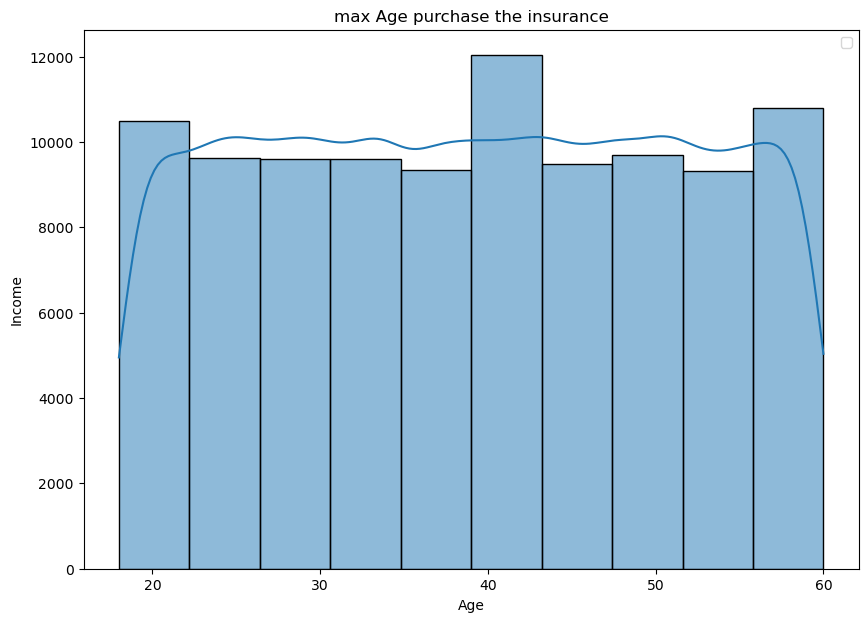

In [9]:
#univariate analysis of "Age" and "Income".
plt.figure(figsize = (10,7))
sns.histplot(data = ins_df,x = "Age",bins = 10,kde = True)
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.title("max Age purchase the insurance")
plt.show()



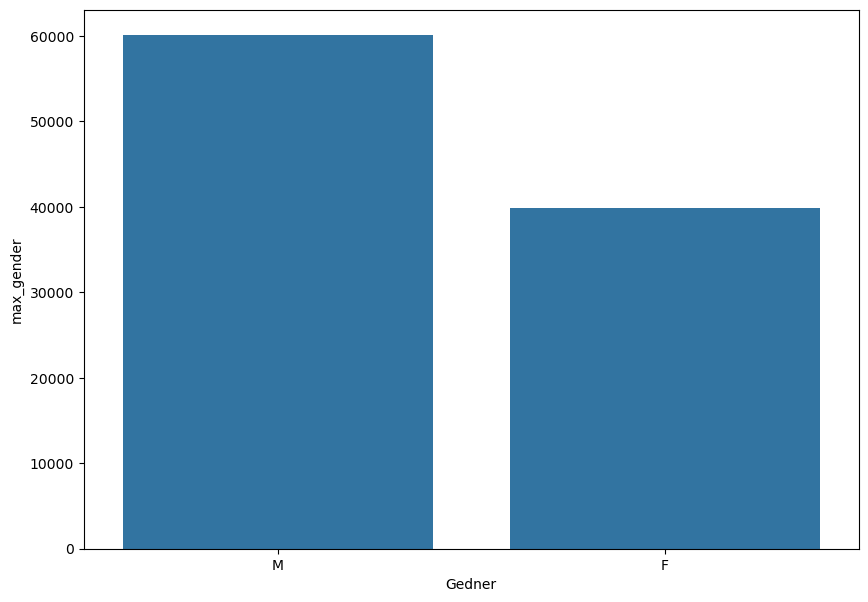

In [11]:
## univariate analysis of gender.
plt.figure(figsize = (10,7))
sns.countplot(data = ins_df, x = "Gender")
plt.xlabel("Gedner")
plt.ylabel("max_gender")
plt.show()

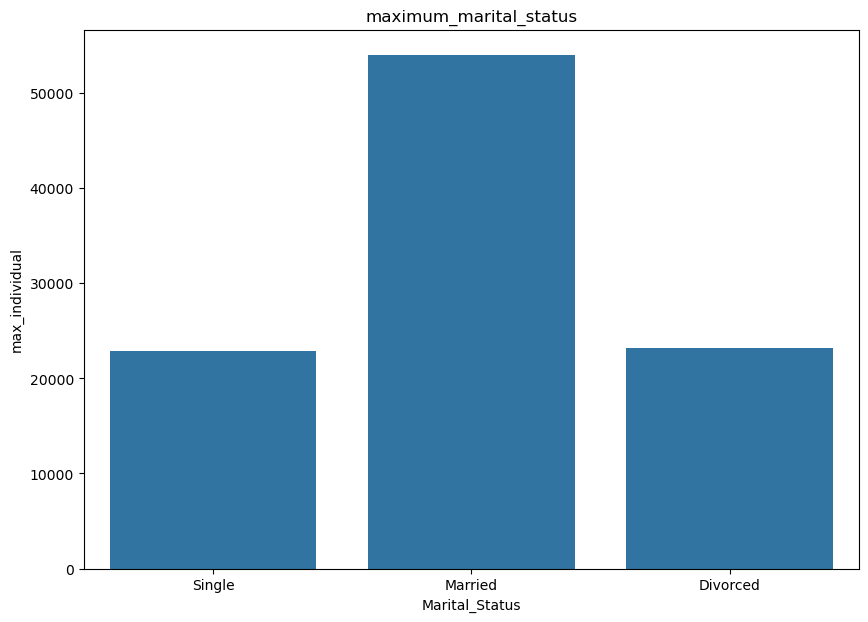

In [15]:
# univariate analysis of Marital_Status
plt.figure(figsize = (10,7))
sns.countplot(data = ins_df, x = "Marital_Status")
plt.xlabel("Marital_Status")
plt.ylabel("max_individual")
plt.title("maximum_marital_status")
plt.show()

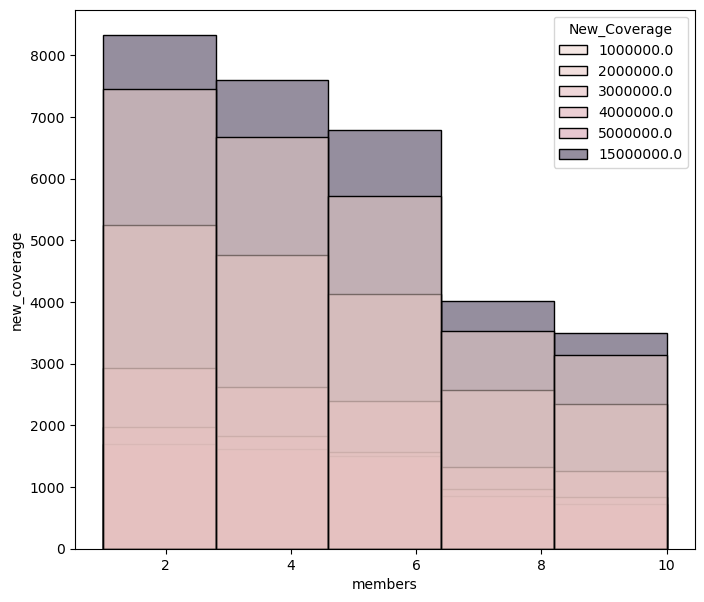

In [26]:
# multi variate analysis according to new_coverage
plt.figure(figsize = (8,7))
sns.histplot(data = ins_df,x = "Family_Members",hue = "New_Coverage",bins = 5)
plt.xlabel("members")
plt.ylabel("new_coverage")
plt.show()

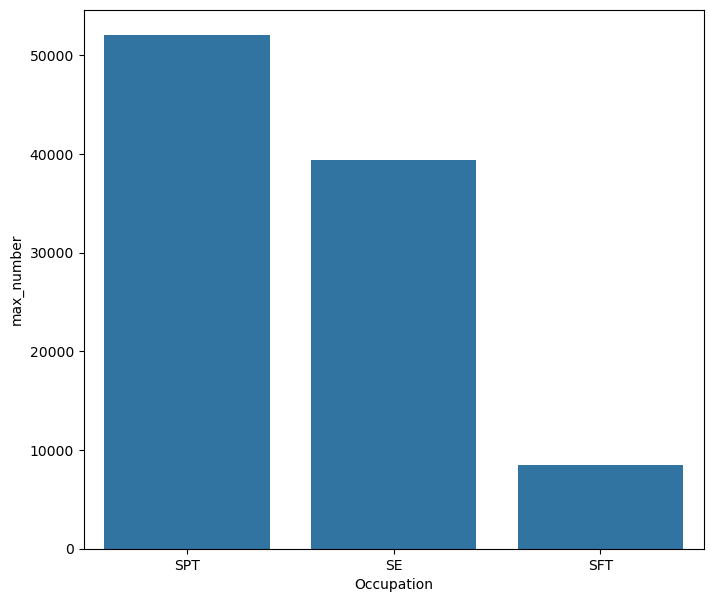

In [27]:
# univariate analysis of Occupation.
plt.figure(figsize = (8,7))
sns.countplot(data = ins_df,x = "Occupation")
plt.xlabel("Occupation")
plt.ylabel("max_number")
plt.show()

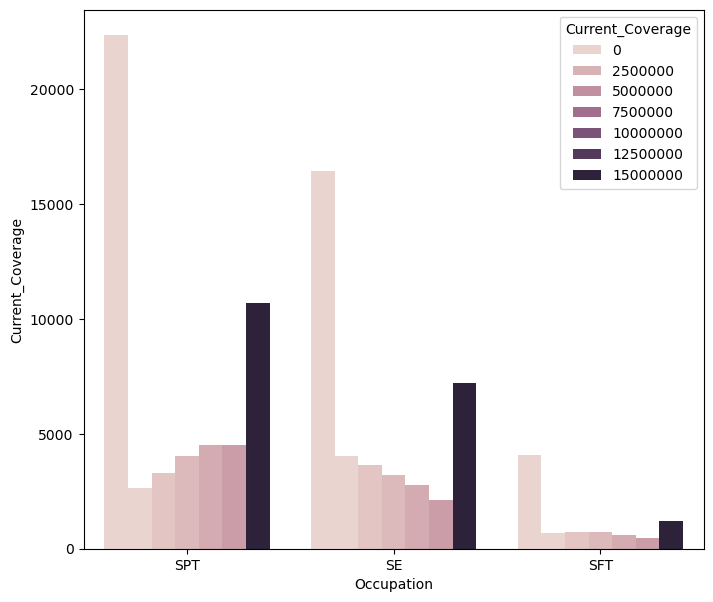

In [29]:
# bivariate analysis of occupation according to Current_Coverage.
plt.figure(figsize = (8,7))
sns.countplot(data = ins_df,x = "Occupation",hue = "Current_Coverage")
plt.xlabel("Occupation")
plt.ylabel("Current_Coverage")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

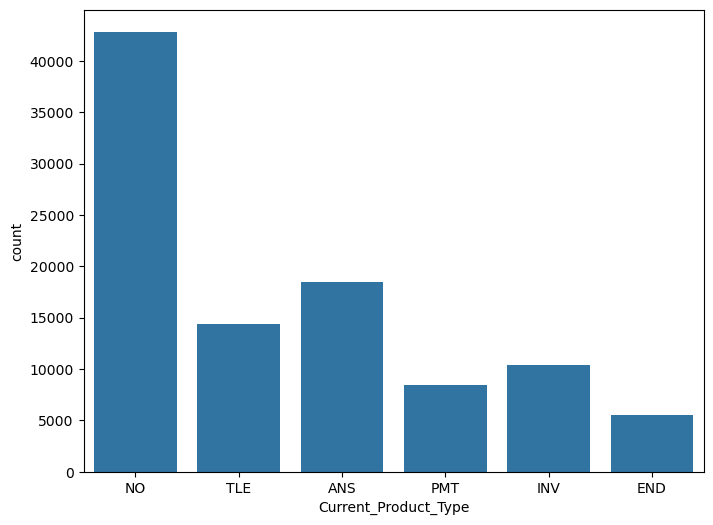

In [31]:
# univariate analysis of Current_Product_Type
plt.figure(figsize = (8,6))
sns.countplot(data = ins_df,x = "Current_Product_Type")
plt.show

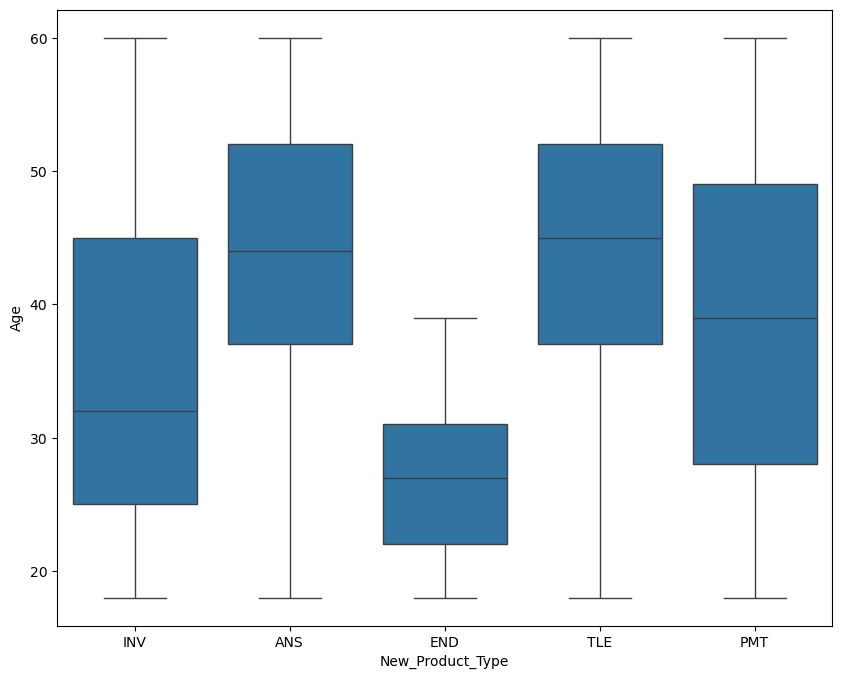

In [36]:
##bivariate analysis of New_Product_Type according to age

plt.figure(figsize = (10,8))
sns.boxplot(data = ins_df,x = "New_Product_Type",y = "Age")
plt.show()

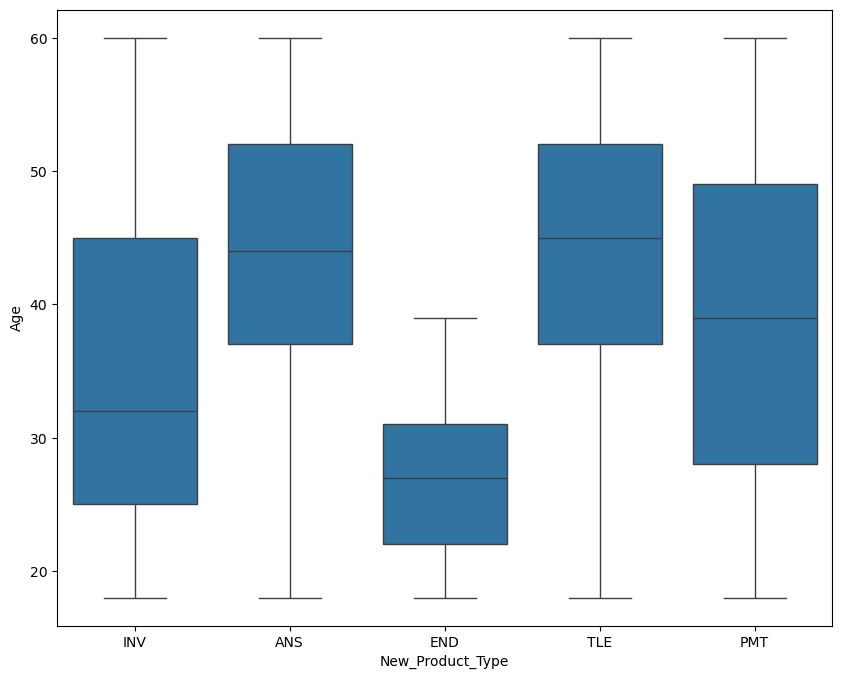

In [37]:
plt.figure(figsize = (10,8))
sns.boxplot(data = ins_df,x = "New_Product_Type",y = "Age")
plt.show()

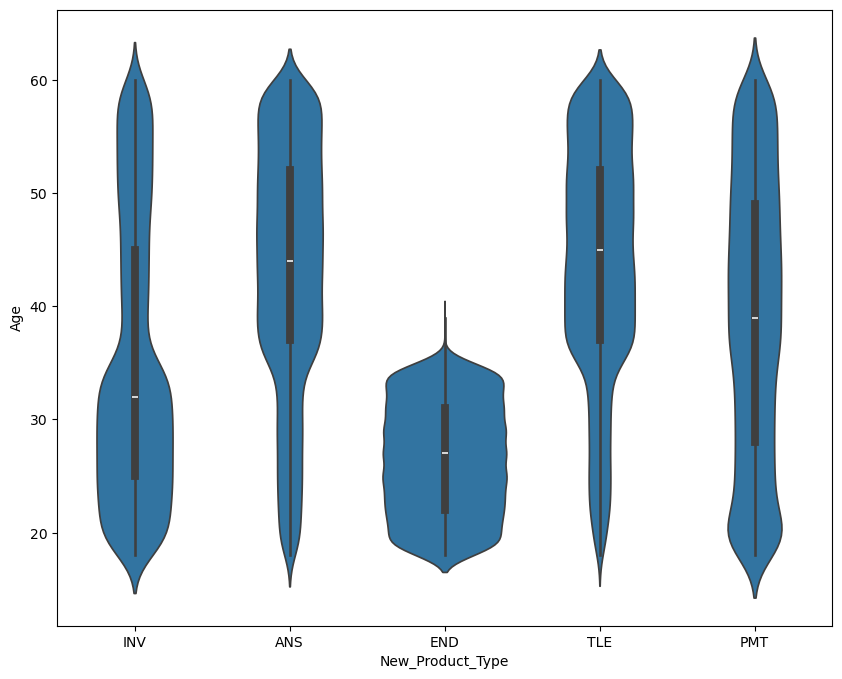

In [38]:
plt.figure(figsize = (10,8))
sns.violinplot(data = ins_df,x = "New_Product_Type",y = "Age")
plt.show()

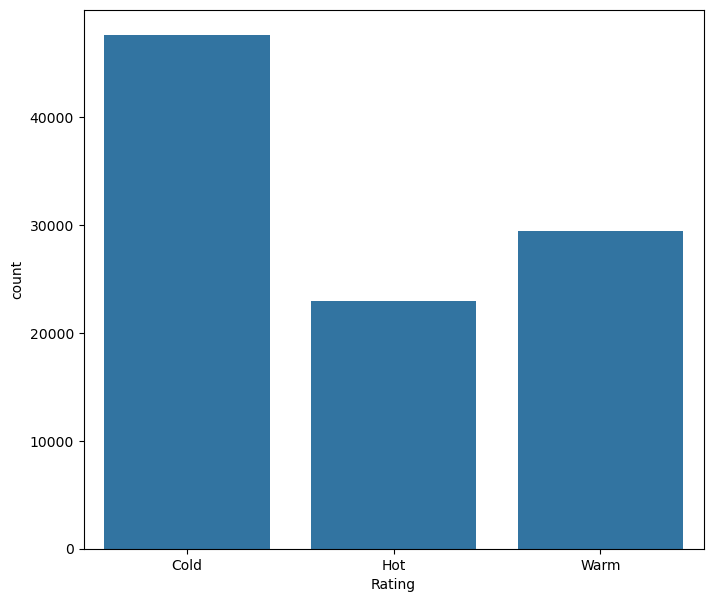

In [39]:
## univariate analysis of Rating
plt.figure(figsize = (8,7))
sns.countplot(data = ins_df, x = "Rating")
plt.show()

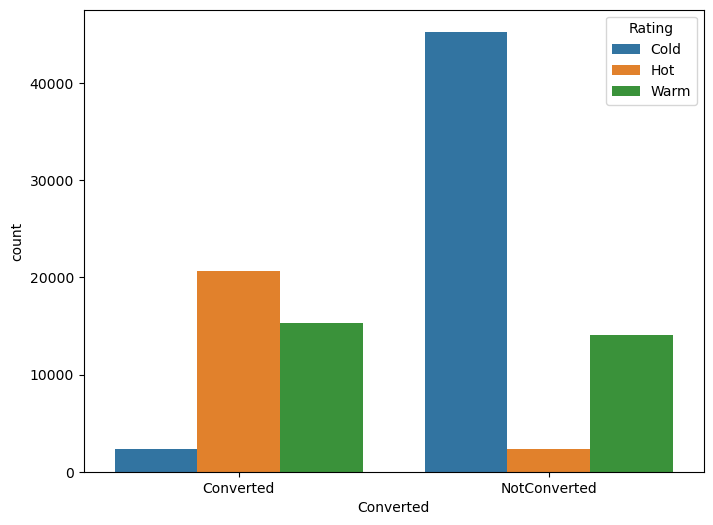

In [43]:
##bivariate analysis of Rating on Converted
plt.figure(figsize = (8,6))
sns.countplot(data = ins_df,x = "Converted", hue = "Rating")
plt.show()